To initially build the simulation model, I will use generated data:
- SPX prices: Geometric Brownian Motion
- Volatility: Mean-reverting Ornstein-Uhlenbeck process
- Option prices: Black-Scholes for ATM calls at 30 and 60 DTE
- Bid-ask spreads: 0.5% spread
- Signals: Generated through random process

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_days = 252
initial_spx = 4500
risk_free_rate = 0.04
initial_vol = 0.15

# Generate dates
dates = pd.date_range(start='2024-01-01', periods=n_days, freq='B')

# 1. Generate SPX price path (Geometric Brownian Motion)
daily_returns = np.random.normal(0.0003, 0.01, n_days)  # ~7.5% annual drift, ~16% annual vol
spx_prices = initial_spx * np.exp(np.cumsum(daily_returns))

# 2. Generate volatility for option pricing (mean-reverting process)
vol_mean = 0.15
vol_speed = 0.5
vol_vol = 0.05
vols = [initial_vol]
for i in range(1, n_days):
    vol_change = vol_speed * (vol_mean - vols[-1]) + vol_vol * np.random.normal(0, 0.01)
    vols.append(max(0.05, vols[-1] + vol_change))  # Floor at 5%
vols = np.array(vols)

# 3. Black-Scholes pricing function
def black_scholes_call(S, K, T, r, sigma):
    """Calculate Black-Scholes call option price"""
    if T <= 0:
        return max(S - K, 0)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

# 4. Generate option prices for each day
option_data = []

for i, date in enumerate(dates):
    S = spx_prices[i]
    K = S  # ATM strike
    vol_30 = vols[i] * 1.02  # Slight term structure: 30 DTE slightly higher vol
    vol_60 = vols[i]
    
    # 30 DTE option
    T_30 = 30 / 252
    price_30 = black_scholes_call(S, K, T_30, risk_free_rate, vol_30)
    bid_30 = price_30 * 0.995  # 0.5% bid-ask spread
    ask_30 = price_30 * 1.005
    
    # 60 DTE option
    T_60 = 60 / 252
    price_60 = black_scholes_call(S, K, T_60, risk_free_rate, vol_60)
    bid_60 = price_60 * 0.995
    ask_60 = price_60 * 1.005
    
    option_data.append({
        'date': date,
        'spx_price': S,
        'strike': K,
        'option_30dte_bid': bid_30,
        'option_30dte_mid': price_30,
        'option_30dte_ask': ask_30,
        'option_60dte_bid': bid_60,
        'option_60dte_mid': price_60,
        'option_60dte_ask': ask_60,
    })

df_options = pd.DataFrame(option_data)

# 5. Generate random signals with realistic patterns
# Use a regime-switching approach to create persistence
signals = []
current_regime = 0  # 0: neutral, 1: long bias, 2: short bias
regime_duration = 0

for i in range(len(df_options)):
    # Randomly switch regimes
    if regime_duration == 0:
        current_regime = np.random.choice([0, 1, 2], p=[0.4, 0.3, 0.3])
        regime_duration = np.random.randint(5, 20)  # Stay in regime for 5-20 days
    
    regime_duration -= 1
    
    # Generate signal based on regime
    if current_regime == 0:  # Neutral
        long_cal = np.random.choice([0, 1], p=[0.5, 0.5])
        short_cal = 0
    elif current_regime == 1:  # Long bias
        long_cal = np.random.choice([1, 2, 3], p=[0.3, 0.5, 0.2])
        short_cal = 0
    else:  # Short bias
        long_cal = 0
        short_cal = np.random.choice([1, 2, 3], p=[0.3, 0.5, 0.2])
    
    signals.append({'long_calendars': long_cal, 'short_calendars': short_cal})

df_options['signal'] = signals

# Display sample
print("Generated Option Data:")
print(df_options.head(25))
print(f"\nTotal days: {len(df_options)}")

Generated Option Data:
         date    spx_price       strike  option_30dte_bid  option_30dte_mid  \
0  2024-01-01  4523.764668  4523.764668        105.634640        106.165468   
1  2024-01-02  4518.869696  4518.869696        106.185657        106.719253   
2  2024-01-03  4549.597560  4549.597560        106.898677        107.435856   
3  2024-01-04  4620.805679  4620.805679        107.749147        108.290600   
4  2024-01-05  4611.381771  4611.381771        107.450080        107.990030   
5  2024-01-08  4601.977838  4601.977838        107.750466        108.291926   
6  2024-01-09  4676.632521  4676.632521        109.121743        109.670093   
7  2024-01-10  4714.074703  4714.074703        110.182137        110.735816   
8  2024-01-11  4693.403008  4693.403008        109.899658        110.451918   
9  2024-01-12  4720.352637  4720.352637        110.074387        110.627525   
10 2024-01-15  4699.938065  4699.938065        109.653996        110.205021   
11 2024-01-16  4679.503589  4

At first, I will not continuously calculate greek exposure, this is something to add later on if there is time.

Initialize tracking variables

In [10]:
class CalendarSpreadSimulator:
    def __init__(self, initial_cash=100000):
        # Position tracking
        self.long_calendars = 0  # Number of long calendar spreads currently held
        self.short_calendars = 0  # Number of short calendar spreads currently held
        
        # Financial tracking
        self.cash = initial_cash
        self.initial_cash = initial_cash
        
        # Performance tracking
        self.daily_pnl = []  # List of daily P&L values
        self.daily_portfolio_value = []  # List of total portfolio values
        self.transaction_costs = 0  # Cumulative transaction costs
        
        # Trade history (optional but useful for debugging)
        self.trades = []  # List of executed trades
        
    def get_portfolio_value(self, long_cal_value, short_cal_value):
        """Calculate current total portfolio value"""
        position_value = (self.long_calendars * long_cal_value - 
                         self.short_calendars * short_cal_value)
        return self.cash + position_value
    
    def get_current_positions(self):
        """Return current position state"""
        return {
            'long_calendars': self.long_calendars,
            'short_calendars': self.short_calendars,
            'cash': self.cash       }

# Initialize simulator
simulator = CalendarSpreadSimulator(initial_cash=100000)

print("Simulator initialized:")
print(f"Initial cash: ${simulator.cash:,.2f}")
print(f"Long calendars: {simulator.long_calendars}")
print(f"Short calendars: {simulator.short_calendars}")

Simulator initialized:
Initial cash: $100,000.00
Long calendars: 0
Short calendars: 0


Main simulation loop, trade execution, and P&L calculation

In [15]:
def calculate_calendar_spread_price(option_60_price, option_30_price):
    """
    Calendar spread price = Long far leg - Short near leg
    For long calendar: Buy 60 DTE, Sell 30 DTE
    Price = option_60_price - option_30_price
    """
    return option_60_price - option_30_price

def execute_trades(simulator, row, use_costs=True):
    """
    Execute trades to reach target position from signal
    
    Parameters:
    - simulator: CalendarSpreadSimulator instance
    - row: Current day's data (prices and signal)
    - use_costs: Whether to include bid-ask spread costs
    """
    # Get target positions from signal
    target_long = row['signal']['long_calendars']
    target_short = row['signal']['short_calendars']
    
    # Current positions
    current_long = simulator.long_calendars
    current_short = simulator.short_calendars
    
    # Calculate trades needed
    long_trade = target_long - current_long  # Positive = buy, Negative = sell
    short_trade = target_short - current_short
    
    # Calculate calendar spread prices
    if use_costs:
        # Buying calendar: pay ask for 60 DTE, receive bid for 30 DTE
        long_cal_buy_price = row['option_60dte_ask'] - row['option_30dte_bid']
        # Selling calendar: receive bid for 60 DTE, pay ask for 30 DTE
        long_cal_sell_price = row['option_60dte_bid'] - row['option_30dte_ask']
        # Short calendar spread prices (reversed)
        short_cal_buy_price = row['option_30dte_ask'] - row['option_60dte_bid']
        short_cal_sell_price = row['option_30dte_bid'] - row['option_60dte_ask']
    else:
        # Use mid prices (no transaction costs)
        long_cal_price = row['option_60dte_mid'] - row['option_30dte_mid']
        long_cal_buy_price = long_cal_sell_price = long_cal_price
        short_cal_price = row['option_30dte_mid'] - row['option_60dte_mid']
        short_cal_buy_price = short_cal_sell_price = short_cal_price
    
    total_cost = 0
    
    # Execute long calendar trades
    if long_trade > 0:  # Buy long calendars
        cost = long_trade * long_cal_buy_price
        simulator.cash -= cost
        simulator.long_calendars += long_trade
        total_cost += abs(long_cal_buy_price - (row['option_60dte_mid'] - row['option_30dte_mid'])) * long_trade
        simulator.trades.append({
            'date': row['date'],
            'type': 'BUY_LONG_CAL',
            'quantity': long_trade,
            'price': long_cal_buy_price,
            'cost': cost
        })
    elif long_trade < 0:  # Sell long calendars
        proceeds = abs(long_trade) * long_cal_sell_price
        simulator.cash += proceeds
        simulator.long_calendars += long_trade  # long_trade is negative
        total_cost += abs(long_cal_sell_price - (row['option_60dte_mid'] - row['option_30dte_mid'])) * abs(long_trade)
        simulator.trades.append({
            'date': row['date'],
            'type': 'SELL_LONG_CAL',
            'quantity': abs(long_trade),
            'price': long_cal_sell_price,
            'proceeds': proceeds
        })
    
    # Execute short calendar trades
    if short_trade > 0:  # Buy short calendars (to open short position)
        proceeds = short_trade * short_cal_sell_price  # You receive premium when opening short
        simulator.cash += proceeds
        simulator.short_calendars += short_trade
        total_cost += abs(short_cal_sell_price - (row['option_30dte_mid'] - row['option_60dte_mid'])) * short_trade
        simulator.trades.append({
            'date': row['date'],
            'type': 'OPEN_SHORT_CAL',
            'quantity': short_trade,
            'price': short_cal_sell_price,
            'proceeds': proceeds
        })
    elif short_trade < 0:  # Close short calendars
        cost = abs(short_trade) * short_cal_buy_price  # You pay to close short
        simulator.cash -= cost
        simulator.short_calendars += short_trade  # short_trade is negative
        total_cost += abs(short_cal_buy_price - (row['option_30dte_mid'] - row['option_60dte_mid'])) * abs(short_trade)
        simulator.trades.append({
            'date': row['date'],
            'type': 'CLOSE_SHORT_CAL',
            'quantity': abs(short_trade),
            'price': short_cal_buy_price,
            'cost': cost
        })
    
    # Accumulate transaction costs
    simulator.transaction_costs += total_cost
    
    return total_cost

# Run simulation loop
simulator = CalendarSpreadSimulator(initial_cash=100000)

for idx, row in df_options.iterrows():
    # Execute trades based on signal
    txn_cost = execute_trades(simulator, row, use_costs=True)
    
    # Calculate current calendar spread values at mid prices
    long_cal_mid = row['option_60dte_mid'] - row['option_30dte_mid']
    short_cal_mid = row['option_30dte_mid'] - row['option_60dte_mid']
    
    # Calculate portfolio value
    portfolio_value = simulator.get_portfolio_value(long_cal_mid, short_cal_mid)
    
    # Calculate daily P&L
    if idx == 0:
        daily_pnl = 0
    else:
        daily_pnl = portfolio_value - simulator.daily_portfolio_value[-1]
    
    # Store results
    simulator.daily_pnl.append(daily_pnl)
    simulator.daily_portfolio_value.append(portfolio_value)

# Display results
print(f"\nSimulation complete!")
print(f"\nFinal positions:")
print(f"Long calendars: {simulator.long_calendars}")
print(f"Short calendars: {simulator.short_calendars}")
print(f"Cash: ${simulator.cash:,.2f}")
print(f"Final portfolio value: ${simulator.daily_portfolio_value[-1]:,.2f}")
print(f"Total return: ${simulator.daily_portfolio_value[-1] - simulator.initial_cash:,.2f}")
print(f"Total transaction costs: ${simulator.transaction_costs:,.2f}")
print(f"\nTotal trades executed: {len(simulator.trades)}")
print(f"\nFirst 5 trades:")
for trade in simulator.trades[:5]:
    print(trade)


Simulation complete!

Final positions:
Long calendars: 0
Short calendars: 1
Cash: $99,705.42
Final portfolio value: $99,756.18
Total return: $-243.82
Total transaction costs: $238.72

Total trades executed: 154

First 5 trades:
{'date': Timestamp('2024-01-03 00:00:00'), 'type': 'BUY_LONG_CAL', 'quantity': 1, 'price': 49.66067231304655, 'cost': 49.66067231304655}
{'date': Timestamp('2024-01-04 00:00:00'), 'type': 'SELL_LONG_CAL', 'quantity': 1, 'price': 47.46294561618126, 'proceeds': 47.46294561618126}
{'date': Timestamp('2024-01-05 00:00:00'), 'type': 'BUY_LONG_CAL', 'quantity': 1, 'price': 49.983472216664424, 'cost': 49.983472216664424}
{'date': Timestamp('2024-01-08 00:00:00'), 'type': 'SELL_LONG_CAL', 'quantity': 1, 'price': 47.43100144488564, 'proceeds': 47.43100144488564}
{'date': Timestamp('2024-01-09 00:00:00'), 'type': 'BUY_LONG_CAL', 'quantity': 1, 'price': 50.74979758440449, 'cost': 50.74979758440449}


Incorporate expirations 

In [17]:
def handle_expiration(simulator, current_day_idx, df_options):
    """
    Handle 30 DTE option expiration every 30 days
    
    When 30 DTE options expire:
    - Long calendar: You're short the 30 DTE option → cash settled
    - Short calendar: You're long the 30 DTE option → cash settled
    - The 60 DTE leg becomes the new 30 DTE leg
    - Need to establish new 60 DTE leg to maintain calendar spread
    
    For simplicity in synthetic data: we'll assume positions are closed at expiration
    and re-opened with new strikes if signal still indicates holding
    """
    
    # Check if it's an expiration day (every 30 trading days)
    if (current_day_idx + 1) % 30 != 0:
        return 0  # No expiration
    
    row = df_options.iloc[current_day_idx]
    expiration_cost = 0
    
    # SPX price at expiration
    spx_price = row['spx_price']
    strike = row['strike']  # ATM strike
    
    # Calculate intrinsic value of 30 DTE option at expiration
    # For ATM calls, intrinsic value = max(SPX - Strike, 0)
    intrinsic_value_30 = max(spx_price - strike, 0)
    
    # Handle LONG calendar spreads at expiration
    if simulator.long_calendars > 0:
        """
        Long calendar = Long 60 DTE, Short 30 DTE
        At 30 DTE expiration:
        - Short 30 DTE settles: you PAY intrinsic value (you're short)
        - Long 60 DTE (now 30 DTE) remains
        
        To maintain calendar spread, need to:
        1. Settle the short 30 DTE leg
        2. Close the remaining 60 DTE leg (or let it become naked)
        
        For this simulation: CLOSE entire calendar spread at expiration
        """
        # Settlement of short 30 DTE leg (you pay if ITM)
        settlement_cash_flow = -simulator.long_calendars * intrinsic_value_30
        
        # Close the 60 DTE leg at current mid price
        # (In reality this is now 30 DTE since 30 days passed)
        closing_value = simulator.long_calendars * row['option_60dte_mid']
        
        # Total cash flow
        total_cash_flow = settlement_cash_flow + closing_value
        simulator.cash += total_cash_flow
        
        expiration_cost += abs(settlement_cash_flow)
        
        simulator.trades.append({
            'date': row['date'],
            'type': 'EXPIRATION_LONG_CAL',
            'quantity': simulator.long_calendars,
            'settlement': settlement_cash_flow,
            'closing_value': closing_value,
            'total_cash_flow': total_cash_flow
        })
        
        # Clear long positions
        simulator.long_calendars = 0
    
    # Handle SHORT calendar spreads at expiration
    if simulator.short_calendars > 0:
        """
        Short calendar = Short 60 DTE, Long 30 DTE
        At 30 DTE expiration:
        - Long 30 DTE settles: you RECEIVE intrinsic value (you're long)
        - Short 60 DTE (now 30 DTE) remains
        
        For this simulation: CLOSE entire calendar spread at expiration
        """
        # Settlement of long 30 DTE leg (you receive if ITM)
        settlement_cash_flow = simulator.short_calendars * intrinsic_value_30
        
        # Close the short 60 DTE leg at current mid price
        # You need to BUY it back to close
        closing_cost = -simulator.short_calendars * row['option_60dte_mid']
        
        # Total cash flow
        total_cash_flow = settlement_cash_flow + closing_cost
        simulator.cash += total_cash_flow
        
        expiration_cost += abs(closing_cost)
        
        simulator.trades.append({
            'date': row['date'],
            'type': 'EXPIRATION_SHORT_CAL',
            'quantity': simulator.short_calendars,
            'settlement': settlement_cash_flow,
            'closing_cost': closing_cost,
            'total_cash_flow': total_cash_flow
        })
        
        # Clear short positions
        simulator.short_calendars = 0
    
    return expiration_cost


# Modified simulation loop with expiration handling
simulator = CalendarSpreadSimulator(initial_cash=100000)

for idx, row in df_options.iterrows():
    # FIRST: Handle expirations (if applicable)
    exp_cost = handle_expiration(simulator, idx, df_options)
    
    # THEN: Execute new trades based on signal
    txn_cost = execute_trades(simulator, row, use_costs=True)
    
    # Calculate current calendar spread values at mid prices
    long_cal_mid = row['option_60dte_mid'] - row['option_30dte_mid']
    short_cal_mid = row['option_30dte_mid'] - row['option_60dte_mid']
    
    # Calculate portfolio value
    portfolio_value = simulator.get_portfolio_value(long_cal_mid, short_cal_mid)
    
    # Calculate daily P&L
    if idx == 0:
        daily_pnl = 0
    else:
        daily_pnl = portfolio_value - simulator.daily_portfolio_value[-1]
    
    # Store results
    simulator.daily_pnl.append(daily_pnl)
    simulator.daily_portfolio_value.append(portfolio_value)
    simulator.transaction_costs += exp_cost

# Display results
print(f"\nSimulation complete!")
print(f"\nFinal positions:")
print(f"Long calendars: {simulator.long_calendars}")
print(f"Short calendars: {simulator.short_calendars}")
print(f"Cash: ${simulator.cash:,.2f}")
print(f"Final portfolio value: ${simulator.daily_portfolio_value[-1]:,.2f}")
print(f"Total return: ${simulator.daily_portfolio_value[-1] - simulator.initial_cash:,.2f}")
print(f"Return %: {((simulator.daily_portfolio_value[-1] / simulator.initial_cash) - 1) * 100:.2f}%")
print(f"Total transaction costs: ${simulator.transaction_costs:,.2f}")
print(f"\nTotal trades executed: {len(simulator.trades)}")

# Show expiration events
expiration_trades = [t for t in simulator.trades if 'EXPIRATION' in t['type']]
print(f"\nExpiration events: {len(expiration_trades)}")
if expiration_trades:
    print("\nFirst expiration event:")
    print(expiration_trades[0])


Simulation complete!

Final positions:
Long calendars: 0
Short calendars: 1
Cash: $99,656.65
Final portfolio value: $99,707.41
Total return: $-292.59
Return %: -0.29%
Total transaction costs: $832.68

Total trades executed: 161

Expiration events: 6

First expiration event:
{'date': Timestamp('2024-03-22 00:00:00'), 'type': 'EXPIRATION_LONG_CAL', 'quantity': 1, 'settlement': -0.0, 'closing_value': 142.0725081643468, 'total_cash_flow': 142.0725081643468}


Performance metrics

In [27]:
def calculate_performance_metrics(simulator):
    """
    Calculate key performance metrics for the strategy
    
    Returns dictionary with:
    - Total return ($)
    - Total return (%)
    - Sharpe ratio
    - Max drawdown (%)
    - Number of trades
    - Win rate (days with positive P&L)
    """
    
    # Total return
    total_return_dollar = simulator.daily_portfolio_value[-1] - simulator.initial_cash
    total_return_pct = (simulator.daily_portfolio_value[-1] / simulator.initial_cash - 1) * 100
    
    # Sharpe ratio (annualized)
    daily_returns = np.diff(simulator.daily_portfolio_value) / simulator.daily_portfolio_value[:-1]
    mean_daily_return = np.mean(daily_returns)
    std_daily_return = np.std(daily_returns)
    
    if std_daily_return > 0:
        sharpe_ratio = (mean_daily_return / std_daily_return) * np.sqrt(252)  # Annualized
    else:
        sharpe_ratio = 0
    
    # Max drawdown
    portfolio_values = np.array(simulator.daily_portfolio_value)
    running_max = np.maximum.accumulate(portfolio_values)
    drawdown = (portfolio_values - running_max) / running_max * 100
    max_drawdown = np.min(drawdown)
    
    # Trade statistics
    num_trades = len(simulator.trades)
    
    # Win rate (percentage of days with positive P&L)
    positive_days = sum(1 for pnl in simulator.daily_pnl if pnl > 0)
    total_days = len(simulator.daily_pnl)
    win_rate = (positive_days / total_days * 100) if total_days > 0 else 0
    
    # Average daily P&L
    avg_daily_pnl = np.mean(simulator.daily_pnl)
    
    metrics = {
        'total_return_dollar': total_return_dollar,
        'total_return_pct': total_return_pct,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown_pct': max_drawdown,
        'num_trades': num_trades,
        'win_rate_pct': win_rate,
        'avg_daily_pnl': avg_daily_pnl,
        'total_transaction_costs': simulator.transaction_costs,
        'final_cash': simulator.cash,
        'final_portfolio_value': simulator.daily_portfolio_value[-1]
    }
    
    return metrics


def print_performance_report(metrics):
    """Pretty print performance metrics"""
    print("\n" + "="*60)
    print("PERFORMANCE METRICS")
    print("="*60)
    print(f"\nReturns:")
    print(f"  Total Return:           ${metrics['total_return_dollar']:,.2f}")
    print(f"  Total Return (%):       {metrics['total_return_pct']:.2f}%")
    print(f"  Avg Daily P&L:          ${metrics['avg_daily_pnl']:,.2f}")
    
    print(f"\nRisk Metrics:")
    print(f"  Sharpe Ratio:           {metrics['sharpe_ratio']:.3f}")
    print(f"  Max Drawdown:           {metrics['max_drawdown_pct']:.2f}%")
    
    print(f"\nTrading Activity:")
    print(f"  Total Trades:           {metrics['num_trades']}")
    print(f"  Win Rate:               {metrics['win_rate_pct']:.2f}%")
    print(f"  Transaction Costs:      ${metrics['total_transaction_costs']:,.2f}")
    
    print(f"\nFinal State:")
    print(f"  Cash:                   ${metrics['final_cash']:,.2f}")
    print(f"  Portfolio Value:        ${metrics['final_portfolio_value']:,.2f}")
    print("="*60)


# Calculate and display metrics
metrics = calculate_performance_metrics(simulator)
print_performance_report(metrics)


PERFORMANCE METRICS

Returns:
  Total Return:           $-292.59
  Total Return (%):       -0.29%
  Avg Daily P&L:          $-1.16

Risk Metrics:
  Sharpe Ratio:           -0.442
  Max Drawdown:           -0.64%

Trading Activity:
  Total Trades:           161
  Win Rate:               21.03%
  Transaction Costs:      $832.68

Final State:
  Cash:                   $99,656.65
  Portfolio Value:        $99,707.41


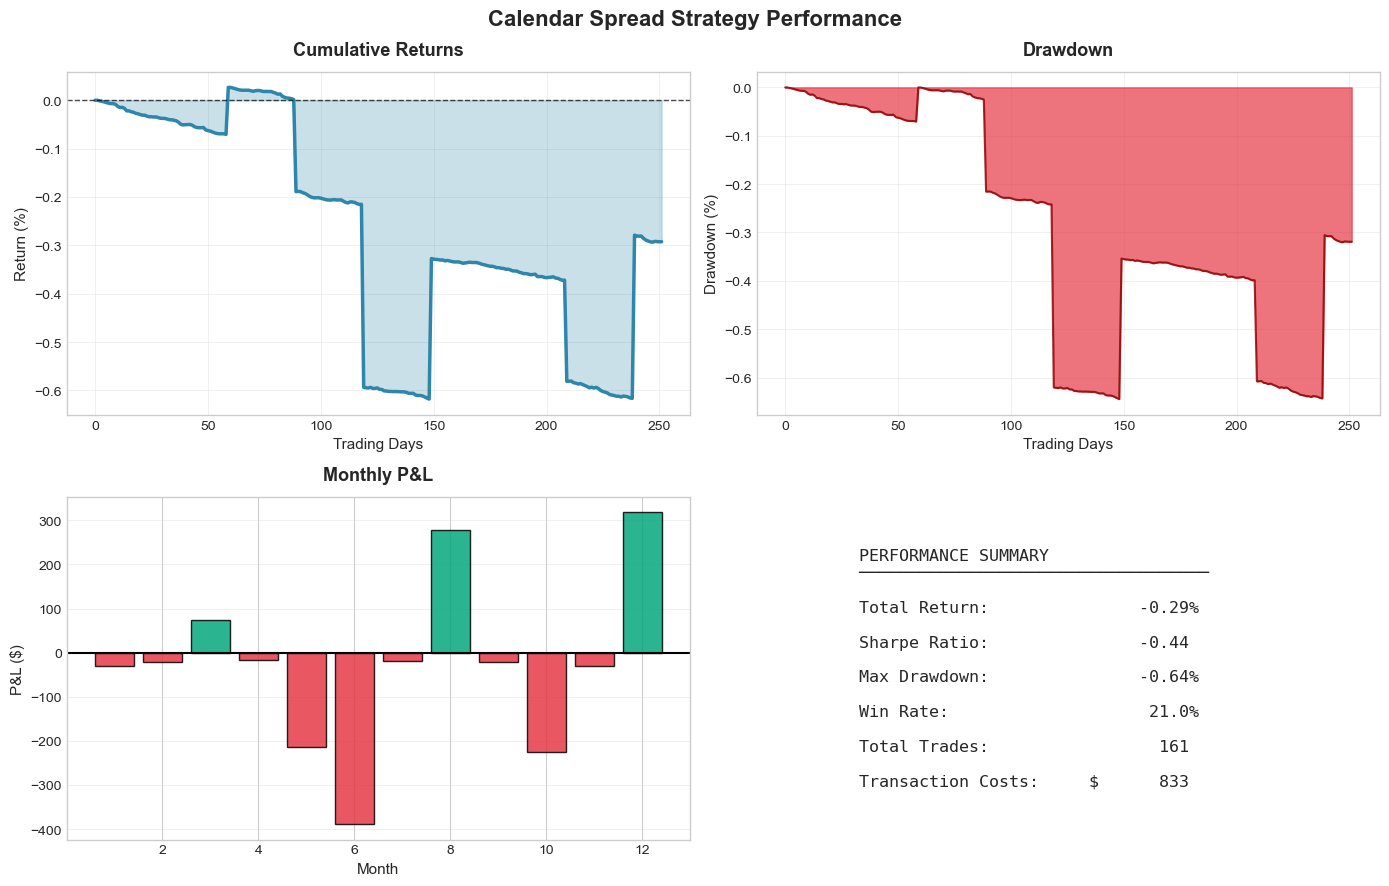

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def plot_clean_performance(simulator):
    """Cleaner, more professional visualizations"""
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Calendar Spread Strategy Performance', fontsize=16, fontweight='bold', y=0.98)
    
    # 1. Cumulative Returns
    ax1 = axes[0, 0]
    returns = (np.array(simulator.daily_portfolio_value) / simulator.initial_cash - 1) * 100
    ax1.plot(returns, linewidth=2.5, color='#2E86AB')
    ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax1.fill_between(range(len(returns)), returns, 0, alpha=0.25, color='#2E86AB')
    ax1.set_title('Cumulative Returns', fontsize=13, fontweight='bold', pad=12)
    ax1.set_ylabel('Return (%)', fontsize=11)
    ax1.set_xlabel('Trading Days', fontsize=11)
    ax1.grid(True, alpha=0.4, linestyle='-', linewidth=0.5)
    
    # 2. Drawdown
    ax2 = axes[0, 1]
    portfolio_values = np.array(simulator.daily_portfolio_value)
    running_max = np.maximum.accumulate(portfolio_values)
    drawdown = (portfolio_values - running_max) / running_max * 100
    ax2.fill_between(range(len(drawdown)), drawdown, 0, alpha=0.7, color='#E63946')
    ax2.plot(drawdown, linewidth=1.5, color='#8B0000', alpha=0.8)
    ax2.set_title('Drawdown', fontsize=13, fontweight='bold', pad=12)
    ax2.set_ylabel('Drawdown (%)', fontsize=11)
    ax2.set_xlabel('Trading Days', fontsize=11)
    ax2.grid(True, alpha=0.4, linestyle='-', linewidth=0.5)
    
    # 3. Monthly P&L
    ax3 = axes[1, 0]
    days_per_month = 21
    num_months = len(simulator.daily_pnl) // days_per_month
    monthly_returns = []
    for i in range(num_months):
        start_idx = i * days_per_month
        end_idx = min((i + 1) * days_per_month, len(simulator.daily_pnl))
        monthly_pnl = sum(simulator.daily_pnl[start_idx:end_idx])
        monthly_returns.append(monthly_pnl)
    
    colors = ['#E63946' if r < 0 else '#06A77D' for r in monthly_returns]
    bars = ax3.bar(range(1, len(monthly_returns) + 1), monthly_returns, color=colors, alpha=0.85, edgecolor='black', linewidth=1)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax3.set_title('Monthly P&L', fontsize=13, fontweight='bold', pad=12)
    ax3.set_ylabel('P&L ($)', fontsize=11)
    ax3.set_xlabel('Month', fontsize=11)
    ax3.grid(True, alpha=0.4, axis='y', linestyle='-', linewidth=0.5)
    
    # 4. Key Metrics Summary (text box without yellow background)
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    # Calculate metrics
    total_return = (simulator.daily_portfolio_value[-1] / simulator.initial_cash - 1) * 100
    daily_returns_arr = np.diff(simulator.daily_portfolio_value) / simulator.daily_portfolio_value[:-1]
    sharpe = (np.mean(daily_returns_arr) / np.std(daily_returns_arr)) * np.sqrt(252) if np.std(daily_returns_arr) > 0 else 0
    max_dd = np.min(drawdown)
    win_rate = sum(1 for pnl in simulator.daily_pnl if pnl > 0) / len(simulator.daily_pnl) * 100
    
    # Create clean metrics display
    metrics_text = f"""
    PERFORMANCE SUMMARY
    {'─' * 35}
    
    Total Return:          {total_return:>10.2f}%
    
    Sharpe Ratio:          {sharpe:>10.2f}
    
    Max Drawdown:          {max_dd:>10.2f}%
    
    Win Rate:              {win_rate:>10.1f}%
    
    Total Trades:          {len(simulator.trades):>10}
    
    Transaction Costs:     ${simulator.transaction_costs:>9,.0f}
    """
    
    ax4.text(0.1, 0.5, metrics_text, fontsize=12, family='monospace',
             verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Generate cleaner plots
fig = plot_clean_performance(simulator)

Probability of Backtest Overfitting Validation

In [39]:
def run_single_backtest(df_data, simulator_class, start_idx, end_idx):
    """
    Run a single backtest on a subset of data with proper error handling
    """
    # Initialize new simulator
    sim = simulator_class(initial_cash=100000)
    
    # Run simulation on subset
    for idx in range(start_idx, end_idx):
        row = df_data.iloc[idx]
        
        # Handle expirations (relative to start of this backtest)
        days_since_start = idx - start_idx
        if days_since_start > 0 and days_since_start % 30 == 0:
            # SPX price at expiration
            spx_price = row['spx_price']
            strike = row['strike']
            intrinsic_value_30 = max(spx_price - strike, 0)
            
            # Close long calendars
            if sim.long_calendars > 0:
                settlement = -sim.long_calendars * intrinsic_value_30
                closing_value = sim.long_calendars * row['option_60dte_mid']
                sim.cash += settlement + closing_value
                sim.long_calendars = 0
            
            # Close short calendars
            if sim.short_calendars > 0:
                settlement = sim.short_calendars * intrinsic_value_30
                closing_cost = -sim.short_calendars * row['option_60dte_mid']
                sim.cash += settlement + closing_cost
                sim.short_calendars = 0
        
        # Execute trades
        execute_trades(sim, row, use_costs=True)
        
        # Calculate portfolio value
        long_cal_mid = row['option_60dte_mid'] - row['option_30dte_mid']
        short_cal_mid = row['option_30dte_mid'] - row['option_60dte_mid']
        portfolio_value = sim.get_portfolio_value(long_cal_mid, short_cal_mid)
        
        # Track P&L
        if len(sim.daily_portfolio_value) == 0:
            daily_pnl = 0
        else:
            daily_pnl = portfolio_value - sim.daily_portfolio_value[-1]
        
        sim.daily_pnl.append(daily_pnl)
        sim.daily_portfolio_value.append(portfolio_value)
    
    # Calculate Sharpe ratio
    if len(sim.daily_portfolio_value) > 20:  # Need minimum data
        daily_returns = np.diff(sim.daily_portfolio_value) / sim.daily_portfolio_value[:-1]
        # Remove any inf or nan values
        daily_returns = daily_returns[np.isfinite(daily_returns)]
        
        if len(daily_returns) > 0 and np.std(daily_returns) > 0:
            sharpe = (np.mean(daily_returns) / np.std(daily_returns)) * np.sqrt(252)
        else:
            sharpe = 0
    else:
        sharpe = 0
    
    return sharpe


def calculate_pbo(df_data, simulator_class, n_splits=6, n_trials=50):
    """
    Calculate Probability of Backtest Overfitting (PBO)
    
    Reduced splits and trials for synthetic data
    """
    
    total_days = len(df_data)
    split_size = total_days // n_splits
    
    # Create split boundaries (ensure minimum 40 days per split)
    splits = []
    for i in range(n_splits):
        start = i * split_size
        end = min((i + 1) * split_size, total_days)
        if end - start >= 40:  # Minimum 40 days
            splits.append((start, end))
    
    n_valid_splits = len(splits)
    print(f"Created {n_valid_splits} data splits of ~{split_size} days each")
    
    if n_valid_splits < 4:
        print("ERROR: Not enough data for PBO validation")
        return None, None, None
    
    is_sharpes_all = []
    oos_sharpes_all = []
    
    for trial in range(n_trials):
        # Randomly assign splits to IS/OOS (50/50)
        n_is = n_valid_splits // 2
        is_indices = np.random.choice(n_valid_splits, size=n_is, replace=False)
        oos_indices = np.array([i for i in range(n_valid_splits) if i not in is_indices])
        
        # Calculate Sharpe on IS splits
        is_sharpes = []
        for idx in is_indices:
            start, end = splits[idx]
            sharpe = run_single_backtest(df_data, simulator_class, start, end)
            if np.isfinite(sharpe):  # Only keep valid Sharpes
                is_sharpes.append(sharpe)
        
        # Calculate Sharpe on OOS splits
        oos_sharpes = []
        for idx in oos_indices:
            start, end = splits[idx]
            sharpe = run_single_backtest(df_data, simulator_class, start, end)
            if np.isfinite(sharpe):  # Only keep valid Sharpes
                oos_sharpes.append(sharpe)
        
        # Only store if we got valid results
        if len(is_sharpes) > 0 and len(oos_sharpes) > 0:
            is_sharpes_all.append(is_sharpes)
            oos_sharpes_all.append(oos_sharpes)
        
        if (trial + 1) % 10 == 0:
            print(f"Completed {trial + 1}/{n_trials} trials")
    
    if len(is_sharpes_all) == 0:
        print("ERROR: No valid trials completed")
        return None, None, None
    
    # Calculate PBO
    oos_worse_count = 0
    for is_sharpes, oos_sharpes in zip(is_sharpes_all, oos_sharpes_all):
        median_is = np.median(is_sharpes)
        median_oos = np.median(oos_sharpes)
        if median_oos < median_is:
            oos_worse_count += 1
    
    pbo = oos_worse_count / len(is_sharpes_all)
    
    return pbo, is_sharpes_all, oos_sharpes_all


# Run PBO validation
pbo_score, is_sharpes, oos_sharpes = calculate_pbo(
    df_options, 
    CalendarSpreadSimulator, 
    n_splits=6,  # Reduced for 252-day dataset
    n_trials=50  # Reduced for speed
)

if pbo_score is not None:
    print(f"\n{'='*60}")
    print(f"PROBABILITY OF BACKTEST OVERFITTING (PBO)")
    print(f"{'='*60}")
    print(f"\nPBO Score: {pbo_score:.2%}")
    print(f"\nInterpretation:")
    if pbo_score < 0.3:
        print("  ✓ Low overfitting risk (PBO < 30%)")
    elif pbo_score < 0.5:
        print("  ⚠ Moderate overfitting risk (30% < PBO < 50%)")
    else:
        print("  ✗ High overfitting risk (PBO > 50%)")
    
    is_flat = [s for trial in is_sharpes for s in trial]
    oos_flat = [s for trial in oos_sharpes for s in trial]
    
    print(f"\nMedian In-Sample Sharpe: {np.median(is_flat):.3f}")
    print(f"Median Out-of-Sample Sharpe: {np.median(oos_flat):.3f}")
    print(f"Mean IS Sharpe: {np.mean(is_flat):.3f}")
    print(f"Mean OOS Sharpe: {np.mean(oos_flat):.3f}")
    print(f"{'='*60}")

Created 6 data splits of ~42 days each
Completed 10/50 trials
Completed 20/50 trials
Completed 30/50 trials
Completed 40/50 trials
Completed 50/50 trials

PROBABILITY OF BACKTEST OVERFITTING (PBO)

PBO Score: 56.00%

Interpretation:
  ✗ High overfitting risk (PBO > 50%)

Median In-Sample Sharpe: 1.684
Median Out-of-Sample Sharpe: 1.218
Mean IS Sharpe: 0.290
Mean OOS Sharpe: 0.100


With random signals, the "strategy" is just noise with some lucky streaks. That's expected. The real test comes with actual predictive signals.